In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import seaborn as sns
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
# import pandas_ta
# import talib
import pickle
# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *
from pklib.pkindicators import calculate_zigzag
from pklib.indicators import *
from pklib.rl import *




## SARSA + >Decision Tree Q-Approximator

In [2]:

def remove_highly_correlated_features(df, threshold=0.9):
    """
    Find features with correlation above a threshold and remove them from the DataFrame.
    
    Parameters:
    df (pd.DataFrame): The original DataFrame.
    threshold (float): The correlation threshold. Features with correlation above this will be removed.
    
    Returns:
    pd.DataFrame: The DataFrame with highly correlated features removed.
    list: List of removed features.
    """
    # Calculate the correlation matrix
    correlation_matrix = df.corr().abs()  # Use absolute correlation values for thresholding
    
    # Create a boolean mask for correlations above the threshold
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    
    # Identify features with correlation greater than the threshold
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    
    # Remove the highly correlated features from the DataFrame
    df_reduced = df.drop(columns=to_drop)
    
    return df_reduced, to_drop


# df_reduced, to_drop = remove_highly_correlated_features(df_features, threshold=0.7)
# len(to_drop), df_reduced.columns

In [53]:
def load_data(exchange, asset, quote, nhours):
    """
    Load and resample candle data.

    Parameters:
    exchange (str): Exchange name (e.g., 'binance').
    asset (str): Asset symbol (e.g., 'BTC').
    quote (str): Quote currency (e.g., 'USDT').
    nhours (int): Number of hours for the timeframe (e.g., 8 for 8-hour candles).

    Returns:
    pd.DataFrame: Resampled candle data.
    """
    df = load_candles(exchange, asset, quote, '1h')
    df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
    return df

def create_indicators(df, nhours):
    """
    Create technical indicators.

    Parameters:
    df (pd.DataFrame): Candle data.
    nhours (int): Number of hours for the timeframe.

    Returns:
    pd.DataFrame: DataFrame with technical indicators.
    """
    # params = {'conversion_periods': 30, 'base_periods': 60, 'lagging_span2_periods': 120, 'displacement': 20}
    # params = {k: int(v * (24/nhours)) for k, v in params.items()}
    params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}

    df_indicators = ichimoku_cloud_indicator(df, params, add_to_original=False
        ).join(df[['high', 'low', 'close', 'open']]
        ).join(create_moving_average_features(
            df, ema_periods=[50, 100],
            sma_periods=[50, 100]
        ))
    return df_indicators

def create_features(df_indicators):
    """
    Create comparison features.

    Parameters:
    df_indicators (pd.DataFrame): DataFrame with technical indicators.

    Returns:
    pd.DataFrame: DataFrame with comparison features.
    """
    compare_columns = [
        ('tenkan', 'kijun', 'close','low'), 
        ('kumo_upper', 'kumo_lower', 'open'), 
        # ('lead_span_A', 'lead_span_B', 'close'),
        # ('sma_50', 'sma_100', 'close'),
        # ('ema_50', 'ema_70', 'close'),
    ]
    df_comp_features = create_comparison_features(df_indicators, compare_columns)
    return df_comp_features

def split_dataframes(dataframes, train_size=0.7):
    """
    Split the input dataframes into training and testing sets.

    Parameters:
    dataframes (list): List of pandas DataFrames to split.
    train_size (float): Proportion of the data to use for training (default is 0.7).

    Returns:
    tuple: (train_dfs, test_dfs) Lists of DataFrames for training and testing.
    """
    train_dfs = []
    test_dfs = []

    for df in dataframes:
        # Calculate the split index
        split_index = int(len(df) * train_size)
        
        # Split the DataFrame
        train_df = df.iloc[:split_index]
        test_df = df.iloc[split_index:]
        
        # Append to the respective lists
        train_dfs.append(train_df)
        test_dfs.append(test_df)

    return train_dfs, test_dfs




# Now you can use these split dataframes for training and testing

# df_comp_features = create_comparison_features(df_indicators, compare_columns)
# # percent_diff_thresholds = [-10, -5,-3,-1, 0, 2, 5, 10]
# # df_percent_diffs = create_signed_difference_features_multi(df_indicators,[
# #             ('close', 'tenkan', percent_diff_thresholds),
# #             ('close', 'kijun', percent_diff_thresholds),
# #             ('tenkan', 'kijun', percent_diff_thresholds),
# #             # ('close', 'ema_21', percent_diff_thresholds),
# #             # ('close', 'ema_14', percent_diff_thresholds),
# #             # ('close', 'ema_7', percent_diff_thresholds),
# #             # ('ema_7', 'close', percent_diff_thresholds),
# #             # ('ema_14', 'close', percent_diff_thresholds),
# #             # ('ema_14', 'ema_21', percent_diff_thresholds),
# #             # ('ema_21', 'ema_50', percent_diff_thresholds),
# #             # ('ema_7', 'ema_21', percent_diff_thresholds),
# #         ])


# # df_percent_diffs, _ = remove_highly_correlated_features(df_percent_diffs, threshold=0.7)

# df_features = df_comp_features#.join(df_percent_diffs).dropna()
# # df_features, features_to_drop = remove_highly_correlated_features(df_features, threshold=0.7)
# # print(f'features_to_drop:')
# # pprint(features_to_drop)


In [12]:

class TradingEnv(gym.Env):
    def __init__(self, df, logprice, lookback_window_size=10, trading_mode='both'):
        super(TradingEnv, self).__init__()
        
        self.df = df
        self.logprice = logprice
        self.lookback_window_size = lookback_window_size
        self.trading_mode = trading_mode  # 'long_only', 'short_only', or 'both'
        
        self.current_step = 0
        self.entry_logprice = None
        self.cumulative_pnl = 0
        self.num_positions = 0
        self.position = 0  # 1 = long, 0 = no position, -1 = short

        # Define action space based on trading mode
        if self.trading_mode == 'long_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = long
        elif self.trading_mode == 'short_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = short
        else:  # 'both'
            self.action_space = Discrete(4)  # 0 = hold, 1 = long, 2 = short, 3 = close position

        # Observation space: OHLCV + technical indicators + entry price + position (flattened lookback period + 2 additional features)
        obs_space_shape = (lookback_window_size * len(self.df.columns) ,)
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)

    def reset(self, seed=None, options=None):
        self.current_step = self.lookback_window_size  # Start after enough steps for lookback
        self.entry_logprice = None
        self.cumulative_pnl = 0
        self.position = 0  # Reset position
        self.num_positions = 0
        self.entry_step = None

        # Initialize the buffer with the lookback window of observations for the starting point
        start_index = max(0, self.current_step - self.lookback_window_size)
        initial_observation = self.df.iloc[start_index:self.current_step].values

        # Pad the history if there are fewer observations than the lookback size
        if len(initial_observation) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(initial_observation), len(self.df.columns)))
            initial_observation = np.vstack((padding, initial_observation))

        # Return the initial flattened observation (1D array) with position and entry price
        # [self.position], self.get_broken_unrealized_thresholds()]
        return np.hstack([initial_observation.flatten()]).astype(np.float32), {'cumulative_pnl': 0}

    def step(self, action):
        current_logprice = self.logprice.iloc[self.current_step]
        reward = 0
        pnl = 0
        trade_info = {}

        # Handle actions based on trading mode
        if self.trading_mode == 'long_only':
            if action == 1 and self.position == 0:  # Open long position
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
            elif action == 0 and self.position == 1:  # Close long position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'short_only':
            if action == 1 and self.position == 0:  # Open short position
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
            elif action == 0 and self.position == -1:  # Close short position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    self.position = 0
                    self.entry_step = None

        else:  # 'both' mode
            if action == 1 and self.position != 1:  # Open or switch to long
                if self.position == -1 and self.entry_logprice is not None:  # Close short position first
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step

            elif action == 2 and self.position != -1:  # Open or switch to short
                if self.position == 1 and self.entry_logprice is not None:  # Close long position first
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step

            elif action == 3 and self.position != 0:  # Close position
                if self.entry_logprice is not None:  # Ensure entry price is set
                    pnl = self.position * (current_logprice - self.entry_logprice)
                    self.cumulative_pnl += pnl
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': self.position,
                            'pnl': pnl
                        }
                    }
                    self.position = 0
                    self.entry_step = None

        # Move to the next step
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1  # End of data
        truncated = False

        # Handle termination case with open position
        if terminated and self.position != 0 and self.entry_logprice is not None:
            pnl = self.position * (current_logprice - self.entry_logprice)
            self.cumulative_pnl += pnl
            trade_info = {
                'trade_info': {
                    'entry_step': self.entry_step,
                    'exit_step': self.current_step,
                    'position': self.position,
                    'pnl': pnl
                }
            }
            self.position = 0  # Close position

        # Calculate reward as pnl or penalize if no position
        reward = pnl
        penalty = 0.05 if self.position == 0 else 0.0  # Encourage taking positions
        reward -= penalty

        # Clip reward to avoid extreme values (optional)
        reward = np.clip(reward, -1, 1)

        # Get the next observation
        obs = self._next_observation()

        # Return observation, reward, termination info, and trade details
        info = {
            'position': self.position,
            'cumulative_pnl': self.cumulative_pnl,
            **trade_info
        }

        return obs, reward, terminated, truncated, info


    def get_unrealized(self):
        if self.position == 0:
            return 0
        return self.position * (self.logprice.iloc[self.current_step] - self.entry_logprice)
    
    def get_broken_unrealized_thresholds(self):
        pct_unrealized = np.expm1(self.get_unrealized())
        thresholds = [-0.5,-0.2,-0.1,-0.05,-0.02, -0.01, 0]
        return is_lower_than_thresholds(pct_unrealized, thresholds) + is_lower_than_thresholds(-pct_unrealized, thresholds)
        
    def _next_observation(self):
        # Handle edge cases where the current step is less than the lookback window size
        start_index = max(0, self.current_step - self.lookback_window_size)
        frame = self.df.iloc[start_index:self.current_step]

        # If the lookback window is smaller than the full lookback size, pad with earlier rows
        if len(frame) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(frame), len(self.df.columns)))
            frame = np.vstack((padding, frame.values))
        else:
            frame = frame.values

        # Return flattened lookback window and append position and entry price
        # , [self.position], self.get_broken_unrealized_thresholds()
        return np.hstack([frame.flatten()]).astype(np.float32)

    def render(self):
        current_logprice = self.logprice.iloc[self.current_step]
        # position_str = "Long" if self.position == 1 else ("Short" if self.position == -1 else "No position")
        print(f"Step: {self.current_step}, # Positions: {self.num_positions}, Cumulative PnL%: {100*np.expm1(self.cumulative_pnl):.2f}")


In [5]:

class SARSAOptTabularAgent:
    def __init__(self, env, epsilon=0.5, alpha=0.3, gamma=0.99, min_epsilon=0.01, epsilon_decay=0.995, early_stopping_steps=1000):
        self.env = env
        self.epsilon = epsilon  # Initial exploration rate
        self.min_epsilon = min_epsilon  # Minimum exploration rate
        self.epsilon_decay = epsilon_decay  # Decay rate for epsilon
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor

        # Early stopping params
        self.early_stopping_steps = early_stopping_steps  # Stop if no improvement in this many steps
        self.best_performance = -float('inf')
        self.no_improvement_counter = 0
        self.total_steps = 0  # Track total steps taken across episodes

        # Initialize a Q-table as a dictionary
        self.q_table = {}

    def get_q_value(self, state, action):
        state_action_key = (tuple(state.flatten()), action)
        return self.q_table.get(state_action_key, 0)

    def update_q_value(self, state, action, new_q_value):
        state_action_key = (tuple(state.flatten()), action)
        self.q_table[state_action_key] = new_q_value

    def choose_action(self, state, use_exploration=True):
        # Epsilon-greedy action selection
        if use_exploration and np.random.random() < self.epsilon:
            return self.env.action_space.sample()  # Explore
        else:
            q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
            return np.argmax(q_values)


    def early_stopping(self, cumulative_reward):
        """
        Implement early stopping if the agent's performance doesn't improve for several steps.
        """
        if cumulative_reward > self.best_performance:
            self.best_performance = cumulative_reward
            self.no_improvement_counter = 0
        else:
            self.no_improvement_counter += 1

        if self.no_improvement_counter >= self.early_stopping_steps:
            print(f'Early stopping triggered after {self.no_improvement_counter} steps without improvement.')
            return True
        return False

    def train(self, num_steps=10000):
        """
        Train the agent using the SARSA algorithm, applying optimizations based on steps.
        """
        cumulative_reward = 0  # Track cumulative reward for early stopping

        while self.total_steps < num_steps:
            # Reset the environment and get the initial state
            state, _ = self.env.reset()
            episode_steps = 0  # Track steps within the episode

            # Choose the initial action
            action = self.choose_action(state)

            done = False

            while not done and self.total_steps < num_steps:
                # Take a step in the environment
                next_state, reward, done, truncated, info = self.env.step(action)

                # Choose the next action using epsilon-greedy strategy
                next_action = self.choose_action(next_state)

                # SARSA update: Q(s, a) <- Q(s, a) + alpha * [r + gamma * Q(s', a') - Q(s, a)]
                current_q_value = self.get_q_value(state, action)
                next_q_value = self.get_q_value(next_state, next_action)
                new_q_value = current_q_value + self.alpha * (reward + self.gamma * next_q_value - current_q_value)

                # Update the Q-table
                self.update_q_value(state, action, new_q_value)

                # Accumulate rewards
                cumulative_reward += reward
                self.total_steps += 1  # Increment global step count
                episode_steps += 1  # Increment episode step count

                # Check for early stopping based on steps
                if self.early_stopping(cumulative_reward):
                    return

                # Move to the next state and action
                state = next_state
                action = next_action

            # Print progress at the end of each episode
            self.env.render()
            print(f'Episode Steps: {episode_steps}, Global Steps: {self.total_steps}, Cumulative PnL(log): {self.env.cumulative_pnl:.2f}, Epsilon: {self.epsilon:.4f}')


    def save_q_table(self, file_path):
        """
        Save the agent's Q-table to a file using pickle.
        
        Parameters:
        - file_path: The path to save the Q-table.
        """
        with open(file_path, 'wb') as f:
            pickle.dump(self.q_table, f)
            
    def load_q_table(self, file_path):
        """
        Load the agent's Q-table from a file using pickle.
        
        Parameters:
        - file_path: The path to load the Q-table from.
        """
        with open(file_path, 'rb') as f:
            self.q_table = pickle.load(f)


    def save_q_table_json(self, file_path):
        """
        Save the agent's Q-table to a file using json.
        
        Parameters:
        - file_path: The path to save the Q-table.
        """
        with open(file_path, 'w') as f:
            json.dump(self.q_table, f)

    def load_q_table_json(self, file_path):
        """
        Load the agent's Q-table from a file using json.
        
        Parameters:
        - file_path: The path to load the Q-table from.
        """
        with open(file_path, 'r') as f:
            self.q_table = json.load(f)

In [6]:
# df[log_prices.isna()]
# df['2018-02-07':'2018-02-10'].ffill()

TRAINING	 nhours=8	num_steps=540.00K,	 lookback_window_size=6
Step: 7691, # Positions: 1100, Cumulative PnL%: 1319.65
Episode Steps: 7685, Global Steps: 7685, Cumulative PnL(log): 2.65, Epsilon: 0.3000
Step: 7691, # Positions: 1134, Cumulative PnL%: 1584.90
Episode Steps: 7685, Global Steps: 15370, Cumulative PnL(log): 2.82, Epsilon: 0.3000
Step: 7691, # Positions: 1166, Cumulative PnL%: 67.21
Episode Steps: 7685, Global Steps: 23055, Cumulative PnL(log): 0.51, Epsilon: 0.3000
Step: 7691, # Positions: 1109, Cumulative PnL%: 389.41
Episode Steps: 7685, Global Steps: 30740, Cumulative PnL(log): 1.59, Epsilon: 0.3000
Step: 7691, # Positions: 1061, Cumulative PnL%: 713.99
Episode Steps: 7685, Global Steps: 38425, Cumulative PnL(log): 2.10, Epsilon: 0.3000
Step: 7691, # Positions: 1154, Cumulative PnL%: 6034.05
Episode Steps: 7685, Global Steps: 46110, Cumulative PnL(log): 4.12, Epsilon: 0.3000
Step: 7691, # Positions: 1079, Cumulative PnL%: 536.68
Episode Steps: 7685, Global Steps: 53795, 

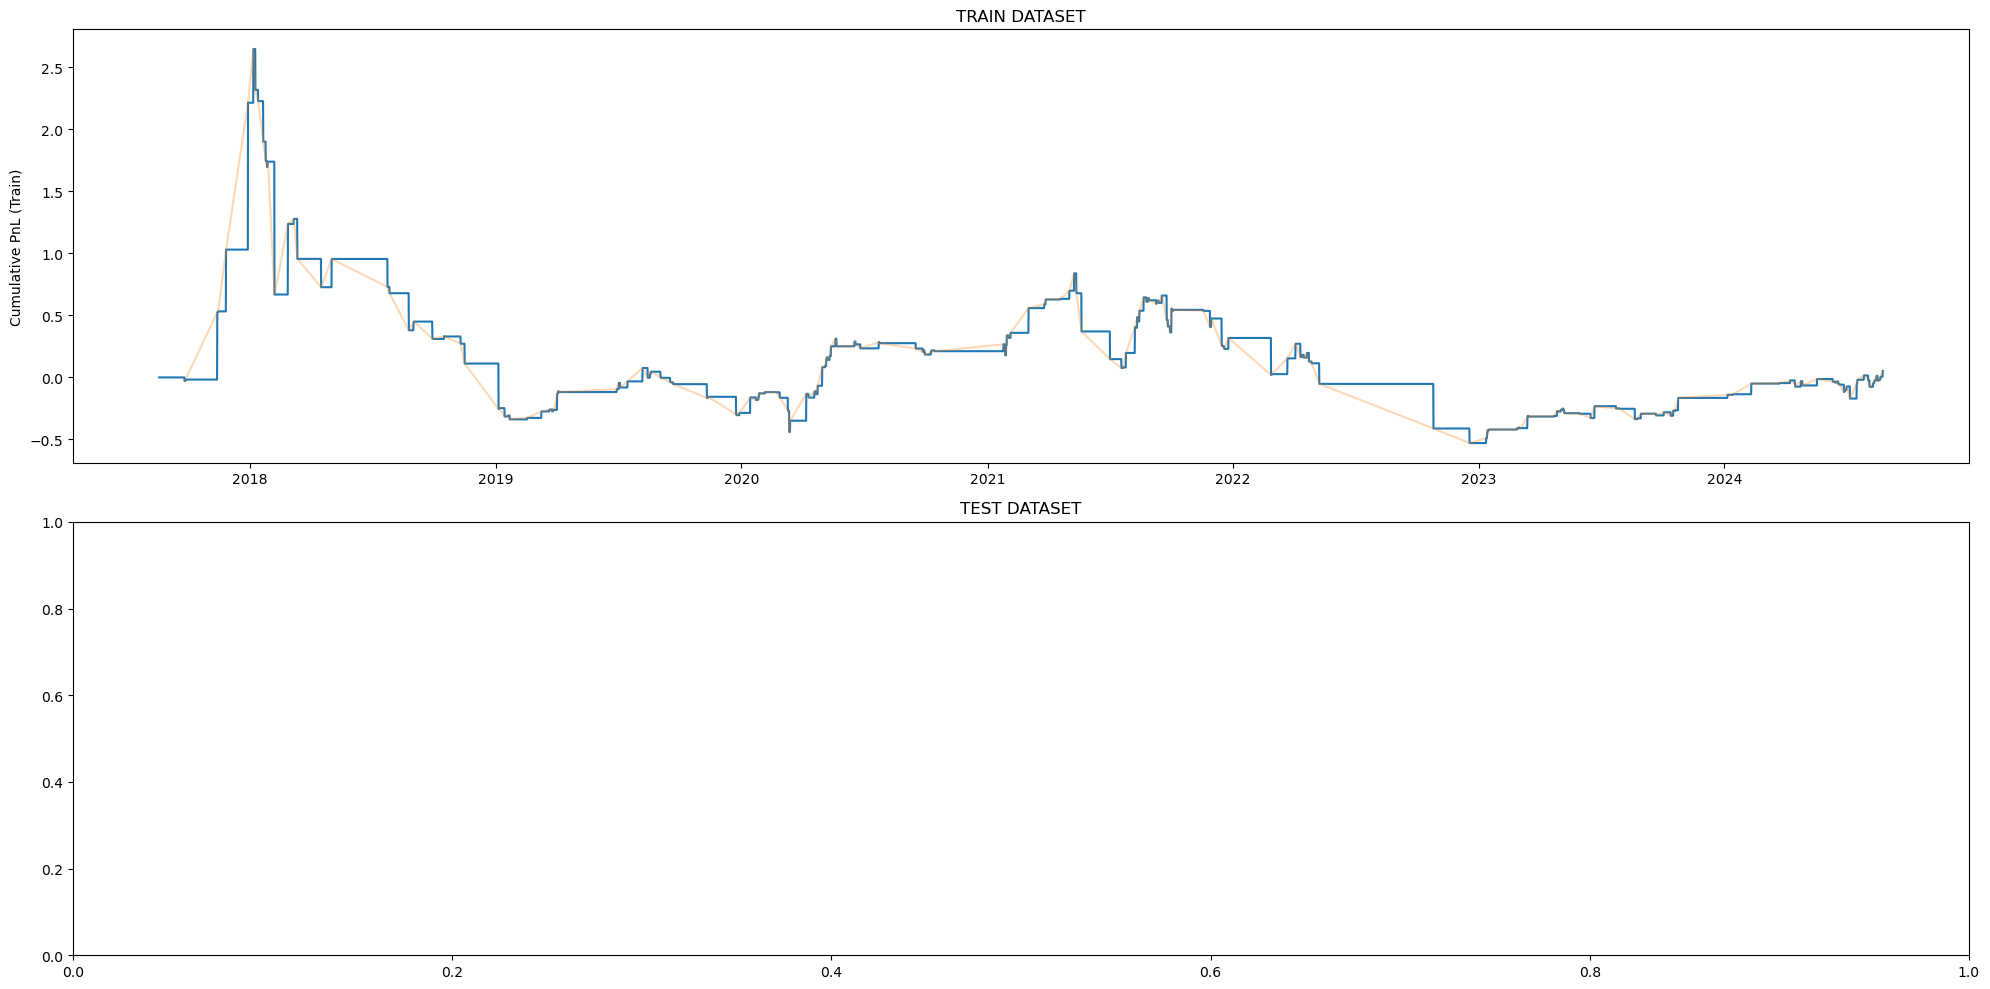

In [58]:
# Parameters
exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 8

lookback_window_size = int(24/nhours) * 2
# lookback_window_size = 3
# Load data and create features
df = load_data(exchange, asset, quote, nhours).ffill()
df_indicators = create_indicators(df, nhours)
df_features = create_features(df_indicators)

# Remove NaNs from features
df_features = df_features.dropna()

# Use df_features index to filter df and df_indicators
df = df.loc[df_features.index]
df_indicators = df_indicators.loc[df_features.index]

# Create log prices
log_prices = np.log(df['close']).ffill()

# Verify all dataframes have the same length
assert len(df) == len(df_indicators) == len(df_features) == len(log_prices), "Dataframe lengths do not match"
# Create log prices

# Split all dataframes at once
(train_df, train_indicators, train_features, train_log_prices), \
(test_df, test_indicators, test_features, test_log_prices) = split_dataframes([df, df_indicators, df_features, log_prices], train_size=1)

trading_mode = 'long_only'
# Initialize the training and testing environments
train_env = TradingEnv(train_features, train_log_prices, lookback_window_size=lookback_window_size, trading_mode=trading_mode)

# Initialize the SARSA agent with overfitting prevention
# agent = SARSATabularAgent(env=train_env)
# agent = SARSAOptTabularAgent(env=train_env, epsilon=.5, alpha=0.3, gamma=0.99, min_epsilon=0.001, epsilon_decay=0.9995, early_stopping_steps=1000000)
agent = SARSAOptTabularAgent(train_env, alpha=0.3, epsilon=0.3, gamma=0.996, early_stopping_steps=1000000)


# Train the agent using SARSA
# num_episodes= int((5000*train_env.observation_space.shape[0]) / len(train_df)) 

num_steps= int((10000*train_env.observation_space.shape[0]))

# print(f'TRAINING\t nhours={nhours}\tnum_episodes={num_episodes},\t lookback_window_size={lookback_window_size}')
print(f'TRAINING\t nhours={nhours}\tnum_steps={num_steps/1000:.2f}K,\t lookback_window_size={lookback_window_size}')
agent.train(num_steps=num_steps)

# with open('SARSA-TradingEnv.pkl', 'wb') as f: pickle.dump(env, f)
# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)


train_backtest_df,train_trades_df = perform_backtest(agent, train_env)

test_backtest_df,test_trades_df = None, None
if(len(test_df) > 0):
    test_env = TradingEnv(test_features, test_log_prices, lookback_window_size=lookback_window_size, trading_mode=trading_mode)
    test_backtest_df,test_trades_df = perform_backtest(agent, test_env)

fig, ax1, ax2 = plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df, test_trades_df)

# # with open('complex_object.pkl', 'rb') as f: env = pickle.load(f)

# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)

In [38]:
train_features

,tenkan_gt_kijun,tenkan_gt_close,kijun_gt_close,kumo_upper_gt_kumo_lower,kumo_upper_gt_close,kumo_lower_gt_close,lead_span_A_gt_lead_span_B,lead_span_A_gt_close,lead_span_B_gt_close,sma_50_gt_sma_100,sma_50_gt_close,sma_100_gt_close,ema_50_gt_ema_70,ema_50_gt_close,ema_70_gt_close
timestamp,,,,,,,,,,,,,,,
2017-08-17 00:00:00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2017-08-17 08:00:00,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2017-08-17 16:00:00,False,False,False,False,False,False,False,False,False,False,True,True,False,True,True
2017-08-18 00:00:00,False,False,False,False,False,False,False,False,False,False,True,True,False,True,True
2017-08-18 08:00:00,False,False,False,False,False,False,False,False,False,False,True,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-15 00:00:00,False,False,True,True,True,True,False,True,True,False,False,False,False,False,True
2022-07-15 08:00:00,False,False,True,True,True,True,False,True,True,False,False,False,False,False,True
2022-07-15 16:00:00,False,False,True,True,True,True,False,True,True,False,False,False,False,False,True


In [ ]:
# agent.save_q_table('SARSA-Agent.pkl')

train_backtest_df,train_trades_df = perform_backtest(agent, train_env)
test_backtest_df,test_trades_df = perform_backtest(agent, test_env)

plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df, test_trades_df)
# agent.save_q_table_json('SARSA-Agent.json')

# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)

In [ ]:

# Create a single figure with two separate axes (not sharing x-axis)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

# Plot for the training dataset
ax1.plot(train_backtest_df.cumulative_pnl.apply(np.expm1)) #.plot(ax=ax1, title='TRAIN DATASET')
ax1.plot(train_trades_df.exit_index,train_trades_df.pnl.cumsum().apply(np.expm1))
ax1.set_ylabel('Cumulative PnL (Train)')

# # # Plot for the training dataset
ax2.plot(test_backtest_df.cumulative_pnl.apply(np.expm1)) #.plot(ax=ax1, title='TRAIN DATASET')
ax2.plot(test_trades_df.exit_index,test_trades_df.pnl.cumsum().apply(np.expm1))
ax2.set_ylabel('Cumulative PnL (Test)')

# Display the figure
plt.tight_layout()
plt.show()

In [ ]:
train_trades_df

In [ ]:

exchange = 'binance';asset = 'AVAX';quote = 'USDT';nhours = 4

# Load data and create features
train_df, test_df, train_log_prices, test_log_prices = load_and_create_features(exchange, asset, quote, nhours, train_size=0)

train_env = TradingEnv(train_df, train_log_prices, lookback_window_size=10)
test_env = TradingEnv(test_df, test_log_prices, lookback_window_size=10)
test_backtest_df, trades = perform_backtest(agent, test_env)
trades
# trades_df['entry_index'] = test_env.logprice.index[trades_df.entry_step]
# trades_df['exit_index'] = test_env.logprice.index[trades_df.exit_step]
# trades_df['entry_logprice'] = test_env.logprice.iloc[trades_df.entry_step]
# trades_df['exit_logprice'] = test_env.logprice.iloc[trades_df.exit_step]

# trades_df['pnl'] = trades_df['exit_logprice'] - trades_df['entry_logprice']
# trades_df.set_index('exit_index')
# ax1 = test_backtest_df.cumulative_pnl.apply(np.expm1).plot(figsize=(20,10),title='TEST DATASET');
# test_trades_df.pnl.cumsum().apply(np.expm1).plot(ax=ax1)
# plt.show();


In [ ]:
test_trades_df

In [ ]:

# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)
# with open('SARSA-Agent.pkl', 'rb') as f: agent = pickle.load(f)

# lookback_window_size = 4
exchange, asset, quote, timeframe = 'binance', 'BTC', 'USDT', '1h'
df = load_candles(exchange,asset, quote, timeframe)['2022-11':]#.iloc[-35000:-5000]
df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
# params = {'conversion_periods':30, 'base_periods':60, 'lagging_span2_periods':120, 'displacement':30}
df_indicators = ichimoku_cloud_indicator(df, **params
    ).join(df[['high','low','close','open']]
    ).join(create_moving_average_features(df, ema_periods=[5,9,14,21,50,120], sma_periods=[5,9,14,21,50,120])
    ).dropna()
df_comp_features = create_comparison_features(df_indicators, compare_columns).dropna()
test_env = TradingEnv(df_comp_features, log_prices, lookback_window_size=lookback_window_size)

df_backtest = perform_backtest(agent, test_env)
df_backtest.cumulative_pnl.apply(np.expm1).plot(figsize=(20,10),title='TEST DATASET')

In [ ]:

# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs,_ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, and cumulative PnL
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(env.cumulative_pnl)
        price_log.append(env.df['close'].iloc[env.current_step])

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': price_log,
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)        
    }, index=env.df.index[lookback_window_size+1:])


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [ ]:

agent.sarsa(num_episodes=10)
with open('SARSA-TradingEnv.pkl', 'wb') as f: pickle.dump(env, f)

In [ ]:
# asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
# data = get_fib_data(asset, quote, timeframe, exchange)

asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
df = load_candles(exchange,asset, quote, timeframe)['2023':]#.iloc[-35000:-5000]
logprice, ldf_ichimoku = load_ichi_df(df, params)
# Wrap the environment
env = DummyVecEnv([lambda: TradingEnv(ldf_ichimoku[features], logprice, lookback_window_size=lookback_window_size)])
# Use VecNormalize to normalize both observations and rewards
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10., clip_reward=10.)
# env = TradingEnv(ldf_ichimoku,ldf_ichimoku.close, lookback_window_size=lookback_window_size)
# env = make_vec_env( lambda: TradingEnv(data, lookback_window_size=10),n_envs=num_cpu,seed=0,vec_env_cls=DummyVecEnv)
# env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

        # Example usage with vectorized results
results_list = backtest_vec(env, lookback_window_size, model=model)
# plot_results_vec(results_list)
plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=None)
# env.reset().shape
# Backtest the environment with random actions
# results = backtest(env, lookback_window_size, model=model)
# plot_results(results)

In [ ]:

plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=(2000, 1000))
# results.sum()

In [ ]:
(results_list)

In [ ]:

import numpy as np
import pandas as pd

def pad_log(log, target_length):
    """Pad the log with NaN values to reach the target length."""
    padding_length = target_length - len(log)
    if padding_length > 0:
        return log + [np.nan] * padding_length
    return log

def backtest_vec(env, lookback_window_size, model=None, render=False):
    # Reset the environment for all parallel environments
    obs = env.reset()  # Only one value (observation) is returned by VecEnv's reset()
    done = np.array([False] * env.num_envs)
    step = 0

    # Initialize logs for all environments
    actions_log = [[] for _ in range(env.num_envs)]
    positions_log = [[] for _ in range(env.num_envs)]
    pnl_log = [[] for _ in range(env.num_envs)]
    price_log = [[] for _ in range(env.num_envs)]

    while not np.all(done):  # Continue until all environments are done
        # Get action from the model if provided, otherwise random action for testing
        if model:
            actions, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            actions = np.random.choice([0, 1, 2, 3], size=env.num_envs)  # Random actions for testing

        # Take a step in all environments (VecEnv step returns 4 values)
        obs, rewards, dones, infos = env.step(actions)

        # 'dones' already includes both termination and truncation statuses
        done = dones

        # Log the action, position, cumulative PnL, and price for each environment
        for i in range(env.num_envs):
            actions_log[i].append(actions[i])
            positions_log[i].append(infos[i].get('position', None))  # Log position
            pnl_log[i].append(infos[i].get('cumulative_pnl', 0))  # Log cumulative PnL
            price_log[i].append(infos[i].get('price', 0))  # Log current price

        # Optionally render the environment (this will render only the first environment for simplicity)
        if render and step % 100 == 0:
            env.render()

        step += 1

    # Determine the maximum log length
    max_log_length = max(len(log) for log in price_log)

    # Pad logs to ensure they all have the same length
    for i in range(env.num_envs):
        actions_log[i] = pad_log(actions_log[i], max_log_length)
        positions_log[i] = pad_log(positions_log[i], max_log_length)
        pnl_log[i] = pad_log(pnl_log[i], max_log_length)
        price_log[i] = pad_log(price_log[i], max_log_length)

    # Convert logs to pandas DataFrames for each environment
    results_list = []
    for i in range(env.num_envs):
        index = env.get_attr('df')[i].index[lookback_window_size+1:lookback_window_size+1+max_log_length]
        results_list.append(pd.DataFrame({
            'Price': price_log[i],
            'Action': actions_log[i],
            'Position': positions_log[i],
            'PnL': np.expm1(pnl_log[i])  # Transform PnL back from log if necessary
        }, index=index))  # Adjust index to match log length

    return results_list

def plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=None):
    """Plot results for each environment alongside the original DataFrame with custom Ichimoku columns."""
    
    for env_index, results in enumerate(results_list):
        # Ensure the indices are aligned between the results and the original df_ichimoku
        aligned_df = df_ichimoku.loc[results.index]  # Align based on the results' index
        
        # If window is specified, apply the (start, len) window
        if window:
            start, length = window
            
            # Perform validation checks
            if start < 0 or start >= len(aligned_df):
                print(f"Warning: Start index {start} out of bounds. Using 0 as start.")
                start = 0  # Reset to start if out of bounds
            
            end = start + length
            if end > len(aligned_df):
                print(f"Warning: End index {end} out of bounds. Adjusting to fit available data.")
                end = len(aligned_df)  # Adjust end to fit the data length
            
            # Apply the slicing window
            aligned_df = aligned_df.iloc[start:end]
            results = results.iloc[start:end]

        fig, ax1 = plt.subplots(figsize=(20, 6))

        # Plot original close price from df_ichimoku on the primary y-axis
        ax1.plot(aligned_df.index, aligned_df['close'], label='Close Price', color='blue')

        # Plot Ichimoku Cloud indicators from df_ichimoku with your custom column names
        ax1.plot(aligned_df.index, aligned_df['tenkan'], label='Tenkan (Conversion Line)', linestyle='--', color='orange')
        ax1.plot(aligned_df.index, aligned_df['kijun'], label='Kijun (Base Line)', linestyle='--', color='red')
        ax1.plot(aligned_df.index, aligned_df['kumo_upper'], label='Kumo Upper', linestyle='--', color='green')
        ax1.plot(aligned_df.index, aligned_df['kumo_lower'], label='Kumo Lower', linestyle='--', color='purple')

        ax1.set_xlabel('Step')
        ax1.set_ylabel('Price & Ichimoku Indicators')

        # Mark buy (open long), sell (open short), and close actions using vertical lines
        buy_signals = results[results['Action'] == 1]
        sell_signals = results[results['Action'] == 2]
        close_signals = results[results['Action'] == 3]

        # Plot vertical lines for buys
        for idx in buy_signals.index:
            ax1.axvline(x=idx, color='green', linestyle='--', label='Buy (Long)', lw=1)

        # Plot vertical lines for sells
        for idx in sell_signals.index:
            ax1.axvline(x=idx, color='red', linestyle='--', label='Sell (Short)', lw=1)

        # Plot vertical lines for closes
        # for idx in close_signals.index:
        #     ax1.axvline(x=idx, color='orange', linestyle='--', label='Close', lw=1)

        # Plot cumulative PnL on the secondary y-axis
        ax2 = ax1.twinx()
        ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.7)
        ax2.set_ylabel('Cumulative PnL')

        # Add legends and titles (to avoid duplicate labels in legends)
        handles, labels = ax1.get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        fig.legend(unique_labels.values(), unique_labels.keys(), loc='upper left')

        plt.title(f'Backtest Results with Custom Ichimoku for Environment {env_index + 1}')

        # Show plot
        plt.show()

        # Optionally print results (you can remove this if you only want plots)
        print(f"Results for Environment {env_index + 1}:")
        print(results)




In [ ]:

# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs,_ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, and cumulative PnL
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(env.cumulative_pnl)
        price_log.append(env.df['close'].iloc[env.current_step])

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': price_log,
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)        
    }, index=env.df.index[lookback_window_size+1:])


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [ ]:
# asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
# data = get_fib_data(asset, quote, timeframe, exchange)

asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
data = load_bb(asset, quote, timeframe, exchange, periods=[7,14,21,50,120], multiplier=2).dropna()
# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('ADA', 'USDT', '8h', 'binance', params)
# Initialize the environment
lookback_window_size=3
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:


# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('BTC', 'USDT', '12h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)

# Initialize the environment
lookback_window_size=10
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# df = get_data('SOL', 'USDT', '4h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '4h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)
# Initialize the environment
lookback_window_size=10
env = TradingEnv(df, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:
import matplotlib.pyplot as plt

# Plot the price, cumulative log-return PnL, and buy/sell signals
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the closing price on the primary y-axis
ax1.plot(env.df.index, env.df['close'], label='Close Price', color='blue', lw=2)

# Plot entry (buy) and exit (sell) signals as vertical lines
for idx, row in tracking_df.iterrows():
    if row['action'] == 2:  # Buy signal
        ax1.axvline(x=idx, color='green', linestyle='--', lw=1, label='Buy')
    elif row['action'] == 0:  # Sell signal
        ax1.axvline(x=idx, color='red', linestyle='--', lw=1, label='Sell')

# Create a secondary y-axis for cumulative log-return PnL
ax2 = ax1.twinx()
ax2.plot(tracking_df.index, tracking_df['cumulative_pnl'], label='Cumulative PnL (Log Returns)', color='black', lw=1.5, linestyle='--')
ax2.set_ylabel('Cumulative PnL (Log Returns)')

# Set labels and title
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.set_title('Agent Trading Performance: Price, Entry/Exit, and Cumulative PnL (Log Returns)')

plt.show()
